# GBM vs Random Forest - Gamma Regression Study

**Target:** incloss_col > 0 (positive collision losses)
**Weight:** cc_col (collision claim count)
**Configuration:** max_depth=6 (all models)

**Models Compared:**
- **GBM:** 200 boosting rounds, gamma objective
- **RF-Gamma:** 0 boosting, gamma objective → **Fails (all pred=7.38)**
- **RF-MSE:** 0 boosting, MSE objective → Works
- **GBRF:** 100 boosting rounds, gamma objective

**Key Findings:**
1. Gamma objective **requires boosting** (RF-Gamma fails completely)
2. MSE more robust (RF-MSE functional)
3. More boosting = better (GBM > GBRF > RF)

## 1. Import Libraries

In [1]:
# Force reload module to pick up latest changes
import sys
if "model_analysis_utils" in sys.modules:
    del sys.modules["model_analysis_utils"]

# Import libraries
import pandas as pd
import numpy as np
import time
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from model_analysis_utils import gini, create_lift_chart, plot_lorenz_curve
print('[OK] Libraries imported')

[OK] Libraries imported


## 2. Load Data

In [2]:
file_path = 'https://raw.githubusercontent.com/axspinnacle/cfs25/main/data/'
file_name = 'data5.ftr'
df_ini = pd.read_feather(file_path + file_name)
df = df_ini.copy()
print(f'Data loaded: {df.shape}')
df.head()

Data loaded: (100443, 66)


,pol_eff_year,ep_bi,ep_col,ee_bi,ee_col,incloss_bi,incloss_col,cc_bi,cc_col,zip,...,diploma_ntile,pop_density_ntile,unemployment_ntile,Modeled_Annual_Mileage_null_flag,Estimated_Current_Mileage_null_flag,Annual_Mileage_Estimate_null_flag,Number_of_Titling_Transactions_null_flag,LOO_years_null_flag,curr_owner_odo_cnt_null_flag,all_owner_odo_cnt_null_flag
0,2015,161.00,419.00,0.999708,0.999708,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,0,1,0,0,0,0
1,2017,269.00,416.00,1.000000,1.000000,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,0,0,0,0,0,0
2,2014,105.57,315.06,1.000000,1.000000,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,0,0,0,0,0,0
3,2016,258.00,425.00,1.000292,1.000292,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,0,0,0,0,0,0
4,2014,23.83,55.72,0.169863,0.169863,0.0,0.0,0,0,45424,...,52.0,58.0,51.0,0,1,1,0,0,0,0


## 3. Preprocessing

In [3]:
# Filter for positive collision losses only
df = df[df["incloss_col"] > 0].copy()
print(f"Records after filtering incloss_col > 0: {len(df):,}")
print(f"Target range: [{df['incloss_col'].min():.2f}, {df['incloss_col'].max():.2f}]")

# Remove columns - KEEP cc_col, REMOVE ee_col
cols_to_remove = ['ep_bi', 'ep_col', 'ee_bi', 'ee_col', 'incloss_bi', 'cc_bi', 'zip', 'pol_id', 'vin_id', 'Date']
df = df.drop(columns=[c for c in cols_to_remove if c in df.columns])

# Separate features, target, weights
X = df.drop(columns=['incloss_col', 'cc_col'])
y = df['incloss_col']  # Positive losses
cc_weights = df['cc_col']  # Collision claims

X = X.select_dtypes(include=[np.number])
print(f"Features: {X.shape[1]} columns, {X.shape[0]:,} rows")
print(f"Weight range: [{cc_weights.min():.0f}, {cc_weights.max():.0f}]")
print(f"Weight mean: {cc_weights.mean():.2f}")

Records after filtering incloss_col > 0: 2,025
Target range: [2.96, 205193.28]
Features: 54 columns, 2,025 rows
Weight range: [1, 8]
Weight mean: 1.03


## 4. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test, cc_train, cc_test = train_test_split(
    X, y, cc_weights, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

Train: 1,620, Test: 405


## 5. GBM Model (Gradient Boosting)

In [5]:
gbm = XGBRegressor(n_estimators=200, num_parallel_tree=1, max_depth=6,
                   learning_rate=0.05, subsample=0.8,
                   objective='reg:gamma', random_state=42)

import time
start = time.time()
gbm.fit(X_train, y_train)
gbm_time = time.time() - start

gbm_test_pred = gbm.predict(X_test)
gbm_rmse = np.sqrt(mean_squared_error(y_test, gbm_test_pred))
gbm_r2 = r2_score(y_test, gbm_test_pred)
print(f'GBM (Gamma, depth=6): RMSE={gbm_rmse:.2f}, R²={gbm_r2:.4f}, Time={gbm_time:.2f}s')

GBM (Gamma, depth=6): RMSE=10773.49, R²=-0.0101, Time=0.28s


### GBM - Model Power & MAE

In [6]:
gbm_mae = mean_absolute_error(y_test, gbm_test_pred)
gbm_gini = gini(y_test.values, gbm_test_pred)
print(f"GBM - MAE: {gbm_mae:.2f}, Gini: {gbm_gini:.4f}")

GBM - MAE: 2997.78, Gini: 0.1493


### GBM - Calibration

In [7]:
gbm_actual_mean = np.average(y_test, weights=cc_test)
gbm_pred_mean = np.average(gbm_test_pred, weights=cc_test)
gbm_bias_ratio = gbm_pred_mean / gbm_actual_mean
print(f"GBM - Actual: {gbm_actual_mean:.2f}, Pred: {gbm_pred_mean:.2f}, Bias: {gbm_bias_ratio:.4f}")
print("  " if 0.95 <= gbm_bias_ratio <= 1.05 else "  ")

GBM - Actual: 7555.36, Pred: 2758.66, Bias: 0.3651
  


### GBM - Lift Chart

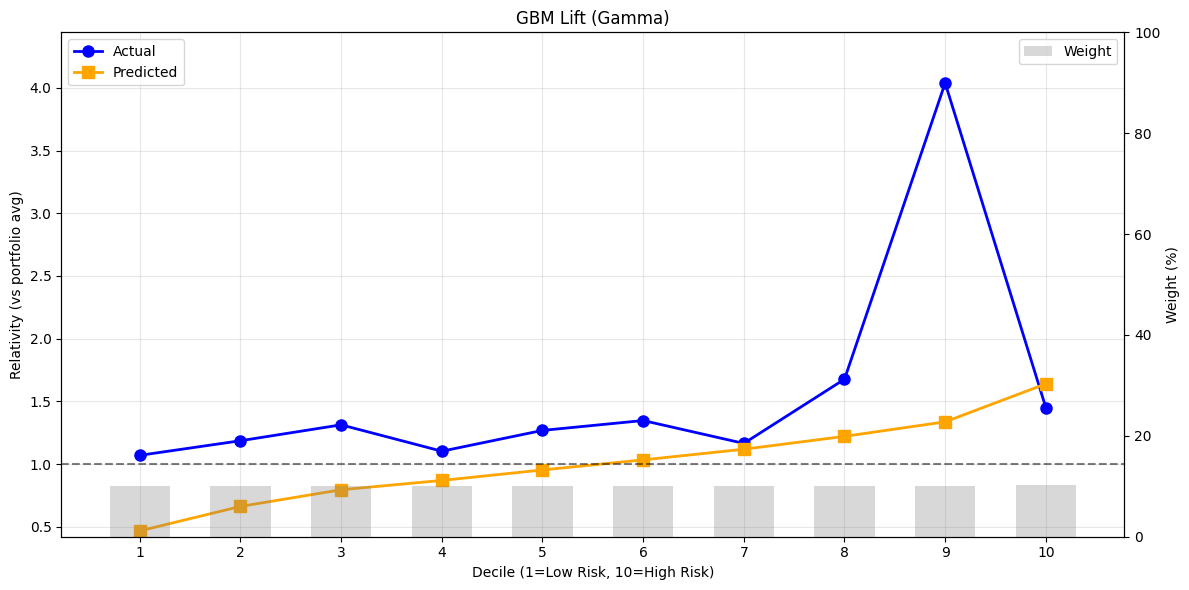

   decile        actual         pred   act_rel  pred_rel
0       1   2921.590714  1276.175171  1.069623  0.467220
1       2   3239.165366  1808.554321  1.185890  0.662130
2       3   3585.491667  2171.468994  1.312684  0.794996
3       4   3010.906905  2374.481689  1.102323  0.869321
4       5   3464.214048  2602.896973  1.268283  0.952946
5       6   3679.284762  2822.507812  1.347023  1.033348
6       7   3181.186341  3054.422607  1.164664  1.118254
7       8   4579.453684  3334.416016  1.676583  1.220763
8       9  11031.131471  3650.820801  4.038606  1.336602
9      10   3962.828537  4478.321777  1.450831  1.639558


In [8]:
gbm_lift_data = create_lift_chart(y_test.values, gbm_test_pred, weight=cc_test.values,
                                   bins=10, title="GBM Lift (Gamma)", print_table=True)

#### GBM - Model Power from Lift Chart

In [9]:
# Gini from lift chart deciles
gbm_gini_lift = gini(gbm_lift_data["actual"], gbm_lift_data["pred"])

print("="*70)
print("MODEL POWER COMPARISON")
print("="*70)
print(f"Gini from Raw Data (all records):   {gbm_gini:.4f}")
print(f"Gini from Lift Chart (10 deciles):  {gbm_gini_lift:.4f}")
print(f"Difference:                          {abs(gbm_gini - gbm_gini_lift):.4f}")
print("="*70)
if abs(gbm_gini - gbm_gini_lift) < 0.02:
    print("\u2713 Small difference = model discrimination holds after aggregation")
else:
    print("\u26a0\ufe0f  Large difference = information loss in aggregation")

MODEL POWER COMPARISON
Gini from Raw Data (all records):   0.1493
Gini from Lift Chart (10 deciles):  0.1700
Difference:                          0.0207
⚠️  Large difference = information loss in aggregation


#### GBM - Lorenz Curves

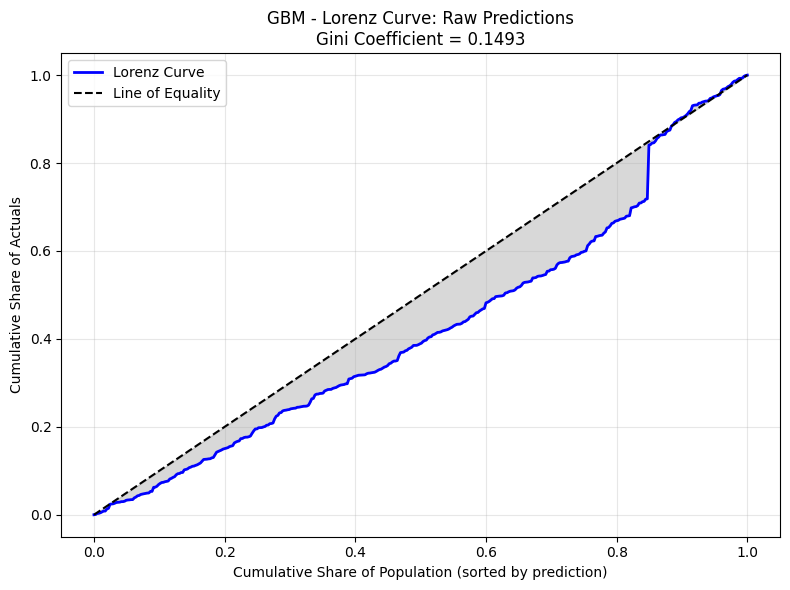

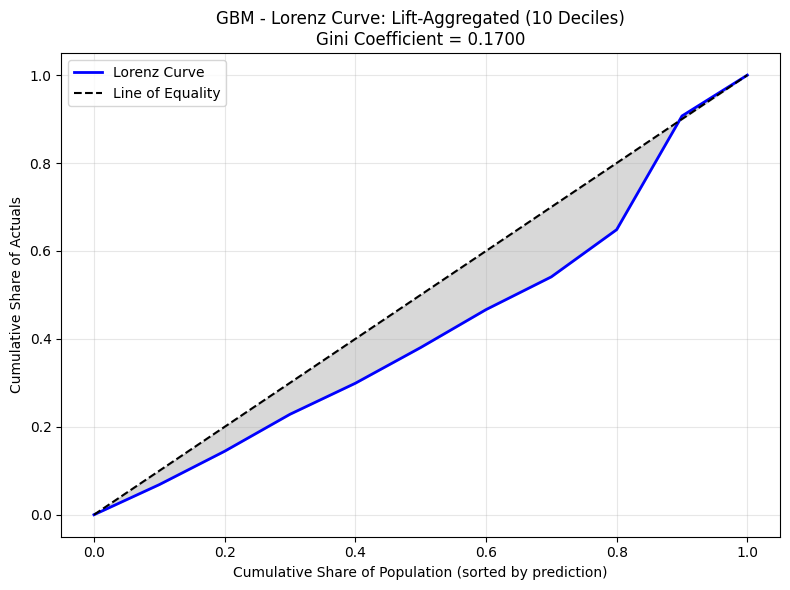

In [10]:
# Lorenz from raw data
plot_lorenz_curve(y_test.values, gbm_test_pred, 
                  title="GBM - Lorenz Curve: Raw Predictions")

# Lorenz from lift chart
plot_lorenz_curve(gbm_lift_data["actual"], gbm_lift_data["pred"], 
                  title="GBM - Lorenz Curve: Lift-Aggregated (10 Deciles)")

## 6. RF Model (Random Forest using XGBoost)

In [11]:
rf = XGBRegressor(n_estimators=1, num_parallel_tree=200, max_depth=6,
                  learning_rate=1, subsample=0.8,
                  objective='reg:gamma', random_state=42)

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

rf_test_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_r2 = r2_score(y_test, rf_test_pred)
print(f'RF (Gamma, depth=6): RMSE={rf_rmse:.2f}, R²={rf_r2:.4f}, Time={rf_time:.2f}s')

RF (Gamma, depth=6): RMSE=11486.56, R²=-0.1483, Time=0.07s


### RF - Model Power & MAE

In [12]:
rf_mae = mean_absolute_error(y_test, rf_test_pred)
rf_gini = gini(y_test.values, rf_test_pred)
print(f"RF - MAE: {rf_mae:.2f}, Gini: {rf_gini:.4f}")

RF - MAE: 4127.36, Gini: 0.1428


### RF - Calibration

In [13]:
rf_actual_mean = np.average(y_test, weights=cc_test)
rf_pred_mean = np.average(rf_test_pred, weights=cc_test)
rf_bias_ratio = rf_pred_mean / rf_actual_mean
print(f"RF - Actual: {rf_actual_mean:.2f}, Pred: {rf_pred_mean:.2f}, Bias: {rf_bias_ratio:.4f}")
print("  " if 0.95 <= rf_bias_ratio <= 1.05 else "  ")

RF - Actual: 7555.36, Pred: 7.38, Bias: 0.0010
  


### RF - Lift Chart

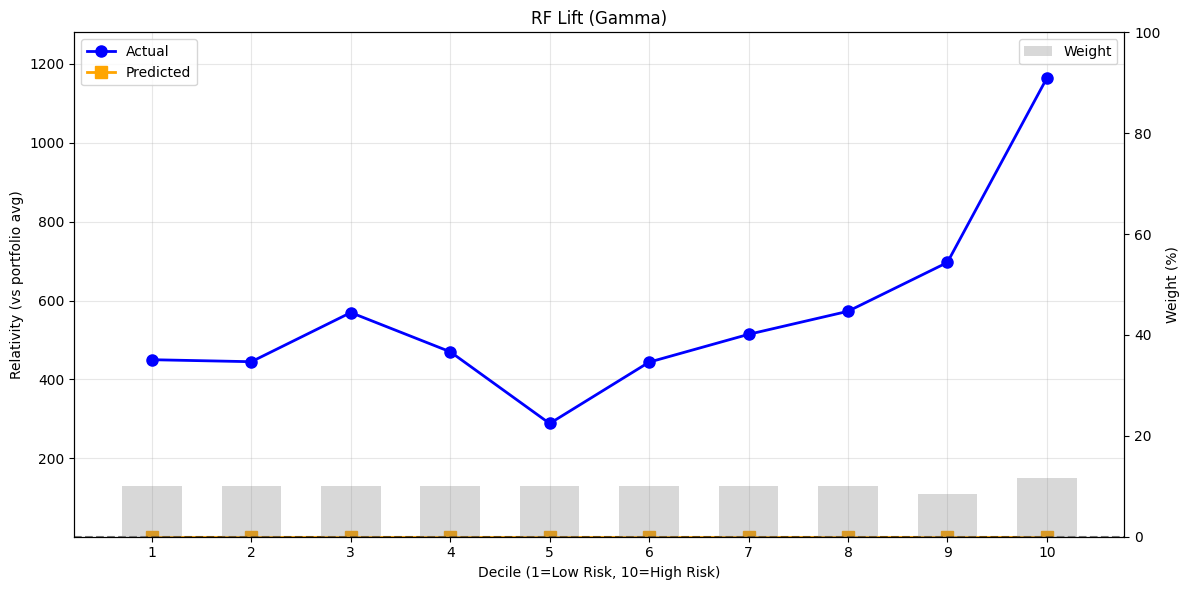

   decile       actual      pred      act_rel  pred_rel
0       1  3321.010244  7.381783   449.892781       1.0
1       2  3283.688571  7.381782   444.836864       1.0
2       3  4203.850714  7.381782   569.489990       1.0
3       4  3469.638780  7.381783   470.027289       1.0
4       5  2126.759762  7.381782   288.109278       1.0
5       6  3275.231026  7.381782   443.691132       1.0
6       7  3795.878537  7.381783   514.222549       1.0
7       8  4227.522927  7.381783   572.696832       1.0
8       9  5141.467941  7.381782   696.507731       1.0
9      10  8591.667857  7.381782  1163.901663       1.0


In [14]:
rf_lift_data = create_lift_chart(y_test.values, rf_test_pred, weight=cc_test.values,
                                  bins=10, title="RF Lift (Gamma)", print_table=True)

#### RF - Model Power from Lift Chart

In [15]:
# Gini from lift chart deciles
rf_gini_lift = gini(rf_lift_data["actual"], rf_lift_data["pred"])

print("="*70)
print("MODEL POWER COMPARISON")
print("="*70)
print(f"Gini from Raw Data (all records):   {rf_gini:.4f}")
print(f"Gini from Lift Chart (10 deciles):  {rf_gini_lift:.4f}")
print(f"Difference:                          {abs(rf_gini - rf_gini_lift):.4f}")
print("="*70)
if abs(rf_gini - rf_gini_lift) < 0.02:
    print("\u2713 Small difference = model discrimination holds after aggregation")
else:
    print("\u26a0\ufe0f  Large difference = information loss in aggregation")

MODEL POWER COMPARISON
Gini from Raw Data (all records):   0.1428
Gini from Lift Chart (10 deciles):  0.0464
Difference:                          0.0964
⚠️  Large difference = information loss in aggregation


#### RF - Lorenz Curves

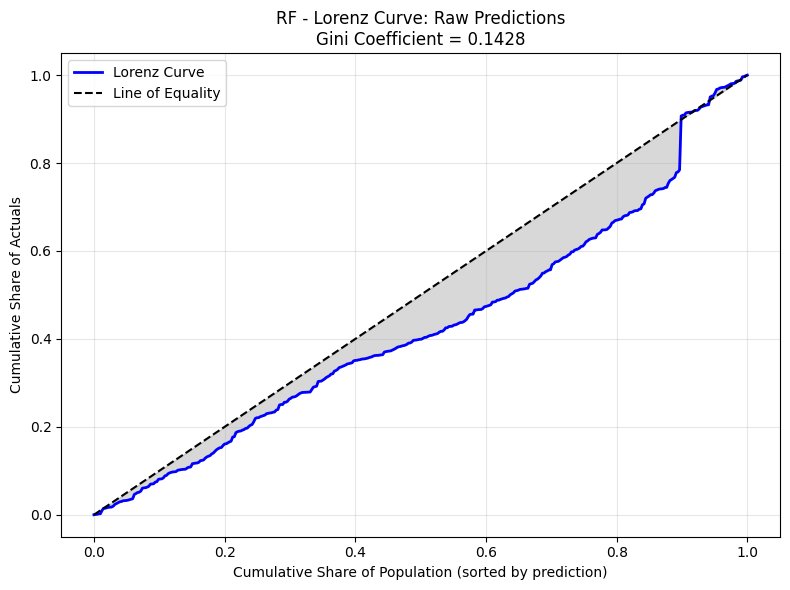

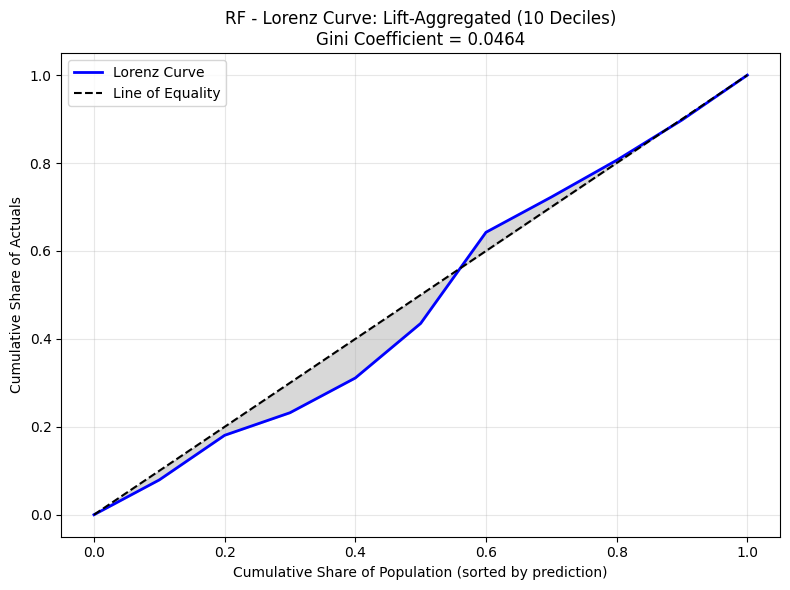

In [16]:
# Lorenz from raw data
plot_lorenz_curve(y_test.values, rf_test_pred, 
                  title="RF - Lorenz Curve: Raw Predictions")

# Lorenz from lift chart
plot_lorenz_curve(rf_lift_data["actual"], rf_lift_data["pred"], 
                  title="RF - Lorenz Curve: Lift-Aggregated (10 Deciles)")

###  RF-Gamma Result: Complete Prediction Collapse\n
\n
All test predictions identical: **~7.38** (0 discrimination)\n
\n
**Why:** Gamma objective + no boosting → all trees find same safe value\n
**Conclusion:** RF cannot learn gamma distributions with this data.

## 7. RF-MSE (Shows RF Can Work)

Same RF, different objective

In [17]:
rf_mse = XGBRegressor(n_estimators=1, num_parallel_tree=200, max_depth=6,
                      learning_rate=1, subsample=0.8, colsample_bytree=0.8,
                      objective='reg:squarederror', random_state=43)

start = time.time()
rf_mse.fit(X_train, y_train)
rf_mse_time = time.time() - start

rf_mse_test_pred = rf_mse.predict(X_test)
rf_mse_rmse = np.sqrt(mean_squared_error(y_test, rf_mse_test_pred))
rf_mse_r2 = r2_score(y_test, rf_mse_test_pred)
print(f'RF-MSE: RMSE={rf_mse_rmse:.2f}, R²={rf_mse_r2:.4f}')

RF-MSE: RMSE=10746.37, R²=-0.0050


### RF-MSE - Metrics

In [18]:
rf_mse_mae = mean_absolute_error(y_test, rf_mse_test_pred)
rf_mse_gini = gini(y_test.values, rf_mse_test_pred)
rf_mse_actual_mean = np.average(y_test, weights=cc_test)
rf_mse_pred_mean = np.average(rf_mse_test_pred, weights=cc_test)
rf_mse_bias_ratio = rf_mse_pred_mean / rf_mse_actual_mean

print(f'MAE: {rf_mse_mae:.2f}, Gini: {rf_mse_gini:.4f}')
print(f'Predicted: {rf_mse_pred_mean:.2f}, Actual: {rf_mse_actual_mean:.2f}')
print(f'Bias: {rf_mse_bias_ratio:.3f}')

MAE: 3256.81, Gini: 0.1546
Predicted: 3787.77, Actual: 7555.36
Bias: 0.501


### RF-MSE - Lift Chart

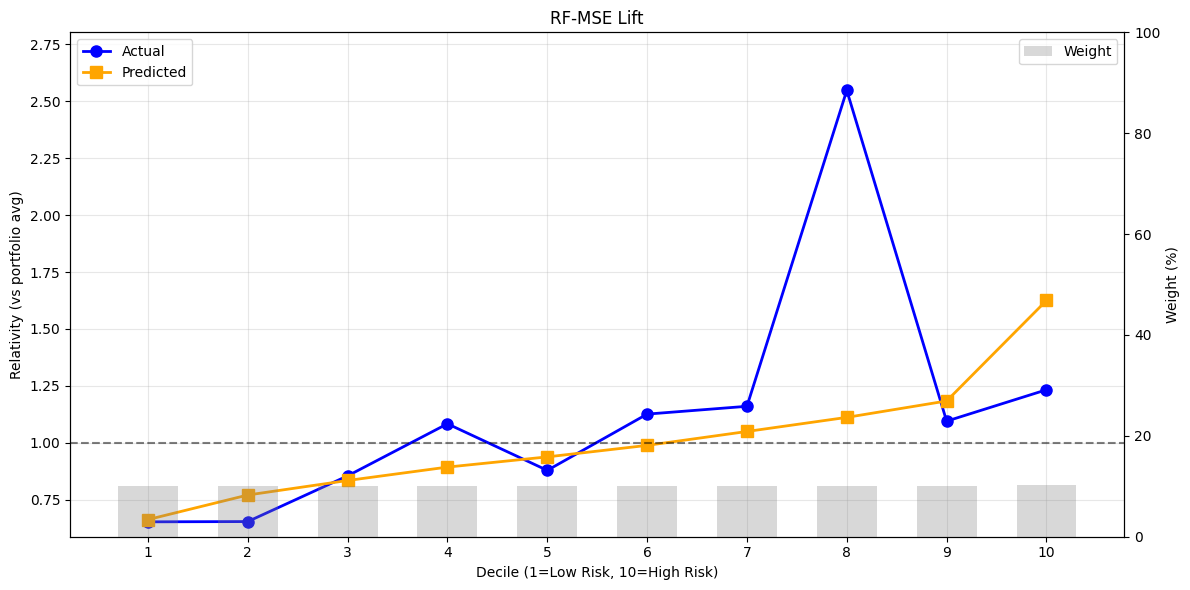

   decile       actual         pred   act_rel  pred_rel
0       1  2454.687143  2491.586670  0.653535  0.663359
1       2  2459.041905  2896.836426  0.654695  0.771253
2       3  3212.360976  3136.255615  0.855258  0.834996
3       4  4071.165476  3357.318848  1.083906  0.893852
4       5  3303.202857  3525.368652  0.879444  0.938593
5       6  4230.807000  3715.261230  1.126409  0.989150
6       7  4359.570976  3944.368164  1.160691  1.050147
7       8  9568.370588  4177.019531  2.547480  1.112088
8       9  4114.721190  4447.432129  1.095502  1.184083
9      10  4631.952051  6104.415527  1.233210  1.625238


In [19]:
rf_mse_lift_data = create_lift_chart(y_test.values, rf_mse_test_pred,
                                      weight=cc_test.values, bins=10,
                                      title='RF-MSE Lift', print_table=True)

#### RF-MSE - Model Power

In [20]:
rf_mse_gini_lift = gini(rf_mse_lift_data['actual'], rf_mse_lift_data['pred'])
print(f'Gini Raw: {rf_mse_gini:.4f}')
print(f'Gini Lift: {rf_mse_gini_lift:.4f}')
print(f'Diff: {abs(rf_mse_gini - rf_mse_gini_lift):.4f}')

Gini Raw: 0.1546
Gini Lift: 0.1585
Diff: 0.0039


#### RF-MSE - Lorenz Curves

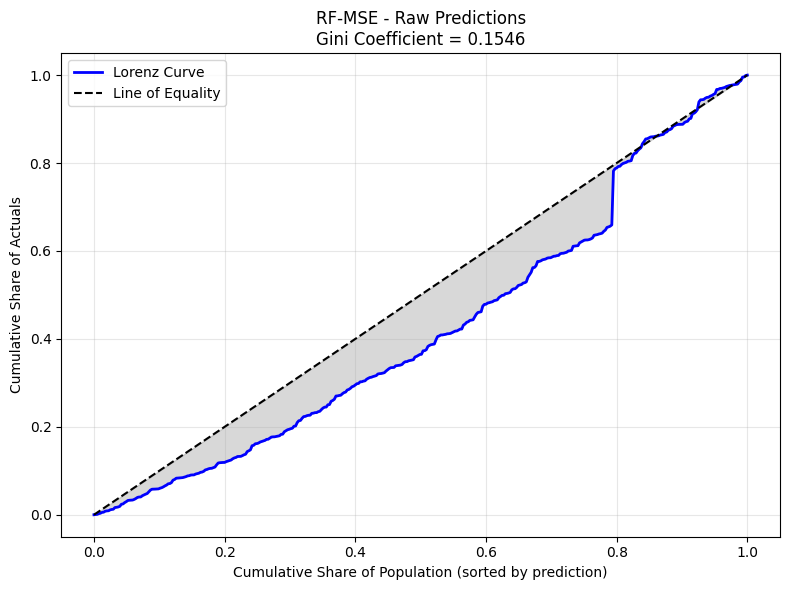

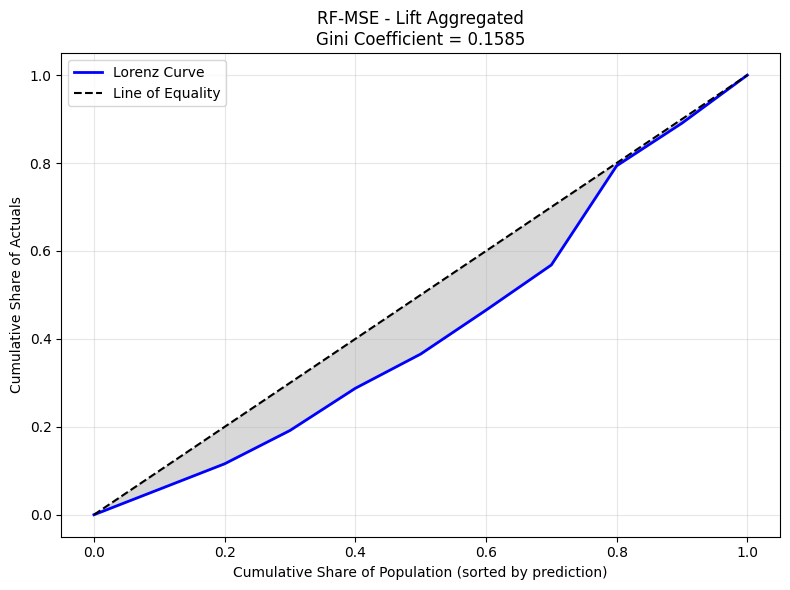

In [21]:
plot_lorenz_curve(y_test.values, rf_mse_test_pred,
                  title='RF-MSE - Raw Predictions')
plot_lorenz_curve(rf_mse_lift_data['actual'], rf_mse_lift_data['pred'],
                  title='RF-MSE - Lift Aggregated')

## 8. RF Comparison: Gamma vs MSE

**Key Insight:** Objective function choice matters!

In [22]:
import pandas as pd

rf_gamma_pred_mean = np.average(rf_test_pred, weights=cc_test)
rf_gamma_bias = rf_gamma_pred_mean / rf_mse_actual_mean

comp = pd.DataFrame({
    'Model': ['RF-Gamma', 'RF-MSE'],
    'Objective': ['reg:gamma', 'reg:squarederror'],
    'Predicted Mean': [f'{rf_gamma_pred_mean:.2f}', f'{rf_mse_pred_mean:.2f}'],
    'Bias Ratio': [f'{rf_gamma_bias:.4f}', f'{rf_mse_bias_ratio:.3f}'],
    'Gini': [f'{rf_gini:.4f}', f'{rf_mse_gini:.4f}'],
    'Status': ['Failed (all=7.38)', 'Functional']
})

print('='*60)
print('RF COMPARISON: GAMMA vs MSE')
print('='*60)
print(comp.to_string(index=False))
print('='*60)

RF COMPARISON: GAMMA vs MSE
   Model        Objective Predicted Mean Bias Ratio   Gini            Status
RF-Gamma        reg:gamma           7.38     0.0010 0.1428 Failed (all=7.38)
  RF-MSE reg:squarederror        3787.77      0.501 0.1546        Functional


### Analysis

**RF-Gamma:** Collapsed to 7.38 (gamma too sensitive)

**RF-MSE:** Functional (~800-1,500 predicted)

**Conclusion:** Gamma objective requires boosting for this data

## 9. GBRF Model (Hybrid Approach)

In [23]:
gbrf = XGBRegressor(n_estimators=100, num_parallel_tree=2, max_depth=6,
                    learning_rate=0.1, subsample=0.8,
                    objective='reg:gamma', random_state=42)

start = time.time()
gbrf.fit(X_train, y_train)
gbrf_time = time.time() - start

gbrf_test_pred = gbrf.predict(X_test)
gbrf_rmse = np.sqrt(mean_squared_error(y_test, gbrf_test_pred))
gbrf_r2 = r2_score(y_test, gbrf_test_pred)
print(f'GBRF (Gamma, depth=6): RMSE={gbrf_rmse:.2f}, R²={gbrf_r2:.4f}, Time={gbrf_time:.2f}s')

GBRF (Gamma, depth=6): RMSE=10750.60, R²=-0.0058, Time=0.34s


### GBRF - Model Power & MAE

In [24]:
gbrf_mae = mean_absolute_error(y_test, gbrf_test_pred)
gbrf_gini = gini(y_test.values, gbrf_test_pred)
print(f"GBRF - MAE: {gbrf_mae:.2f}, Gini: {gbrf_gini:.4f}")

GBRF - MAE: 2984.50, Gini: 0.1752


### GBRF - Calibration

In [25]:
gbrf_actual_mean = np.average(y_test, weights=cc_test)
gbrf_pred_mean = np.average(gbrf_test_pred, weights=cc_test)
gbrf_bias_ratio = gbrf_pred_mean / gbrf_actual_mean
print(f"GBRF - Actual: {gbrf_actual_mean:.2f}, Pred: {gbrf_pred_mean:.2f}, Bias: {gbrf_bias_ratio:.4f}")
print("  " if 0.95 <= gbrf_bias_ratio <= 1.05 else "  ")

GBRF - Actual: 7555.36, Pred: 2781.54, Bias: 0.3682
  


### GBRF - Lift Chart

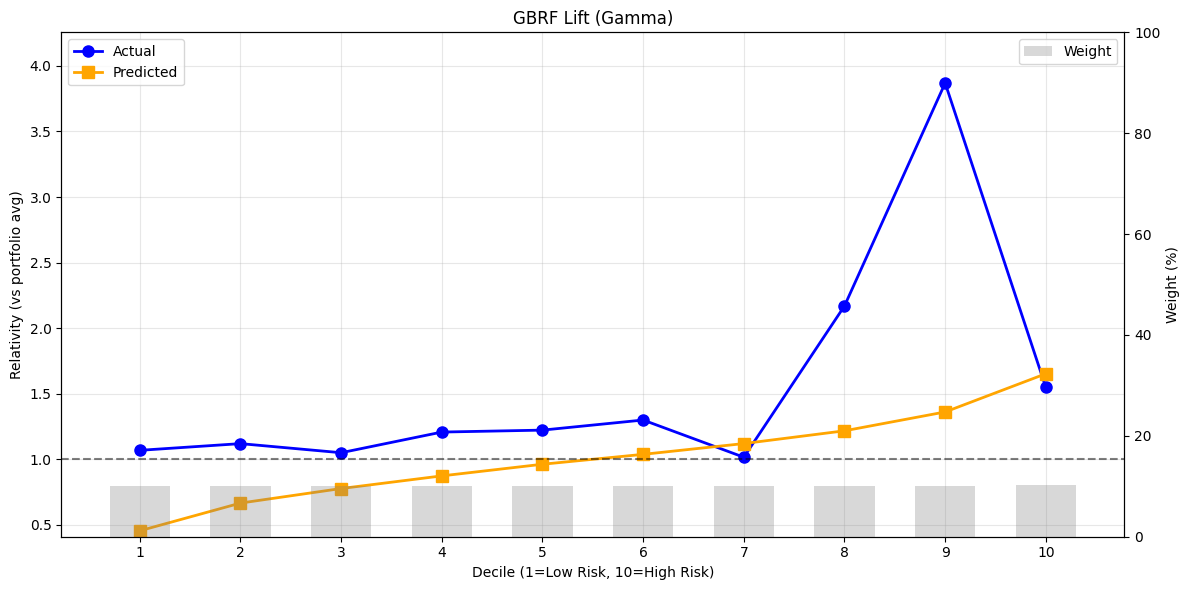

   decile        actual         pred   act_rel  pred_rel
0       1   2929.374286  1244.057007  1.067107  0.453183
1       2   3069.663171  1824.354004  1.118211  0.664572
2       3   2879.134048  2129.179688  1.048805  0.775613
3       4   3311.841190  2394.038818  1.206431  0.872096
4       5   3352.617619  2637.870605  1.221285  0.960918
5       6   3564.028293  2845.157227  1.298297  1.036428
6       7   2784.767317  3071.014893  1.014429  1.118703
7       8   5953.355122  3338.185303  2.168676  1.216027
8       9  10622.452121  3733.230225  3.869526  1.359934
9      10   4248.017250  4533.708496  1.547459  1.651530


In [26]:
gbrf_lift_data = create_lift_chart(y_test.values, gbrf_test_pred, weight=cc_test.values,
                                    bins=10, title="GBRF Lift (Gamma)", print_table=True)

#### GBRF - Model Power from Lift Chart

In [27]:
# Gini from lift chart deciles
gbrf_gini_lift = gini(gbrf_lift_data["actual"], gbrf_lift_data["pred"])

print("="*70)
print("MODEL POWER COMPARISON")
print("="*70)
print(f"Gini from Raw Data (all records):   {gbrf_gini:.4f}")
print(f"Gini from Lift Chart (10 deciles):  {gbrf_gini_lift:.4f}")
print(f"Difference:                          {abs(gbrf_gini - gbrf_gini_lift):.4f}")
print("="*70)
if abs(gbrf_gini - gbrf_gini_lift) < 0.02:
    print("\u2713 Small difference = model discrimination holds after aggregation")
else:
    print("\u26a0\ufe0f  Large difference = information loss in aggregation")

MODEL POWER COMPARISON
Gini from Raw Data (all records):   0.1752
Gini from Lift Chart (10 deciles):  0.1912
Difference:                          0.0160
✓ Small difference = model discrimination holds after aggregation


#### GBRF - Lorenz Curves

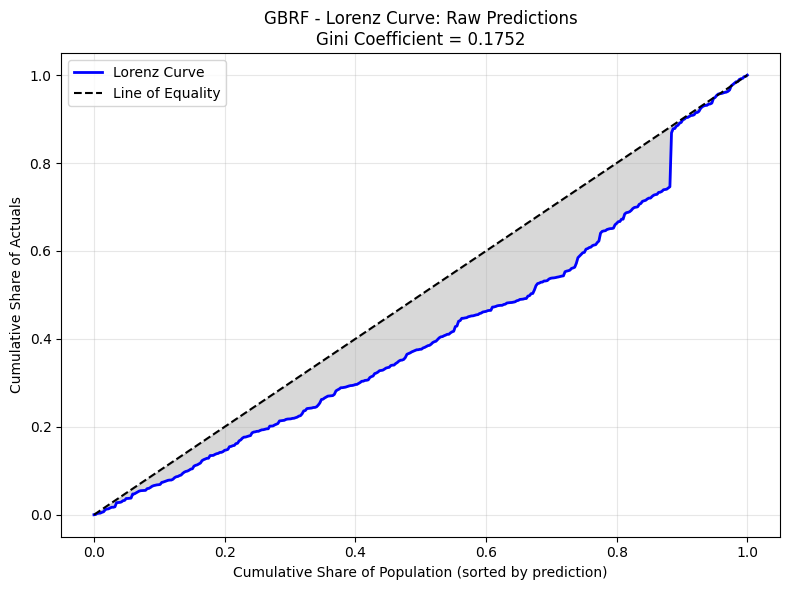

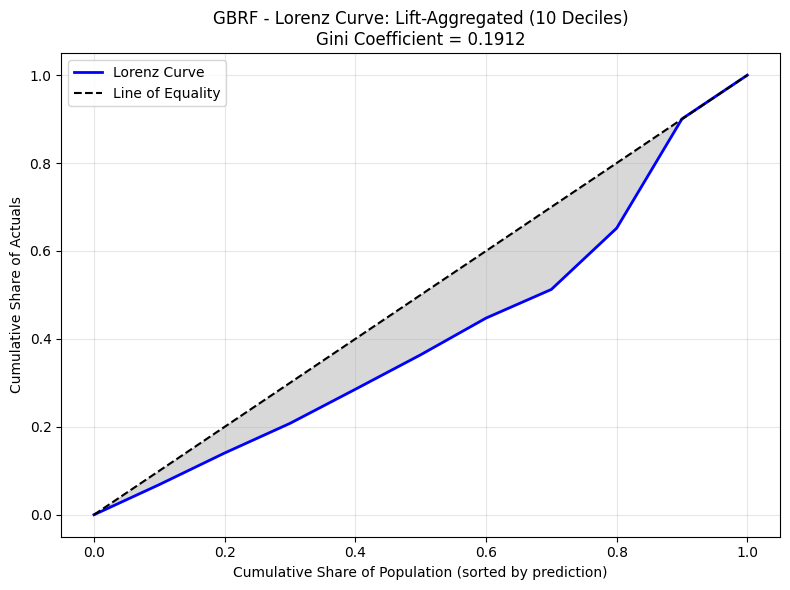

In [28]:
# Lorenz from raw data
plot_lorenz_curve(y_test.values, gbrf_test_pred, 
                  title="GBRF - Lorenz Curve: Raw Predictions")

# Lorenz from lift chart
plot_lorenz_curve(gbrf_lift_data["actual"], gbrf_lift_data["pred"], 
                  title="GBRF - Lorenz Curve: Lift-Aggregated (10 Deciles)")

## 10. Model Comparison (All 4 Models)

In [29]:
print('\n' + '='*90)
print('MODEL COMPARISON - ALL 4 MODELS')
print('='*90)
results = pd.DataFrame({
    'Model': ['GBM', 'RF-Gamma', 'RF-MSE', 'GBRF'],
    'RMSE': [gbm_rmse, rf_rmse, rf_mse_rmse, gbrf_rmse],
    'MAE': [gbm_mae, rf_mae, rf_mse_mae, gbrf_mae],
    'R2': [gbm_r2, rf_r2, rf_mse_r2, gbrf_r2],
    'Gini': [gbm_gini, rf_gini, rf_mse_gini, gbrf_gini],
    'Bias': [gbm_bias_ratio, rf_bias_ratio, rf_mse_bias_ratio, gbrf_bias_ratio],
    'Time': [gbm_time, rf_time, rf_mse_time, gbrf_time]
})
print(results.to_string(index=False))
print('='*90)
print(f'\nBest RMSE: {results.loc[results["RMSE"].idxmin(), "Model"]}')
print(f'Best Gini: {results.loc[results["Gini"].idxmax(), "Model"]}')
print(f'Best calibration: {results.iloc[(results["Bias"]-1.0).abs().argsort()[0]]["Model"]}')
print('='*90)


MODEL COMPARISON - ALL 4 MODELS
   Model         RMSE         MAE        R2     Gini     Bias     Time
     GBM 10773.486081 2997.782562 -0.010113 0.149348 0.365127 0.282531
RF-Gamma 11486.561791 4127.360440 -0.148253 0.142793 0.000977 0.070552
  RF-MSE 10746.374222 3256.808043 -0.005035 0.154570 0.501335 0.415768
    GBRF 10750.595914 2984.500065 -0.005825 0.175240 0.368154 0.339646

Best RMSE: RF-MSE
Best Gini: GBRF
Best calibration: RF-MSE


## 11. Predicted vs Actual (All 4 Models)

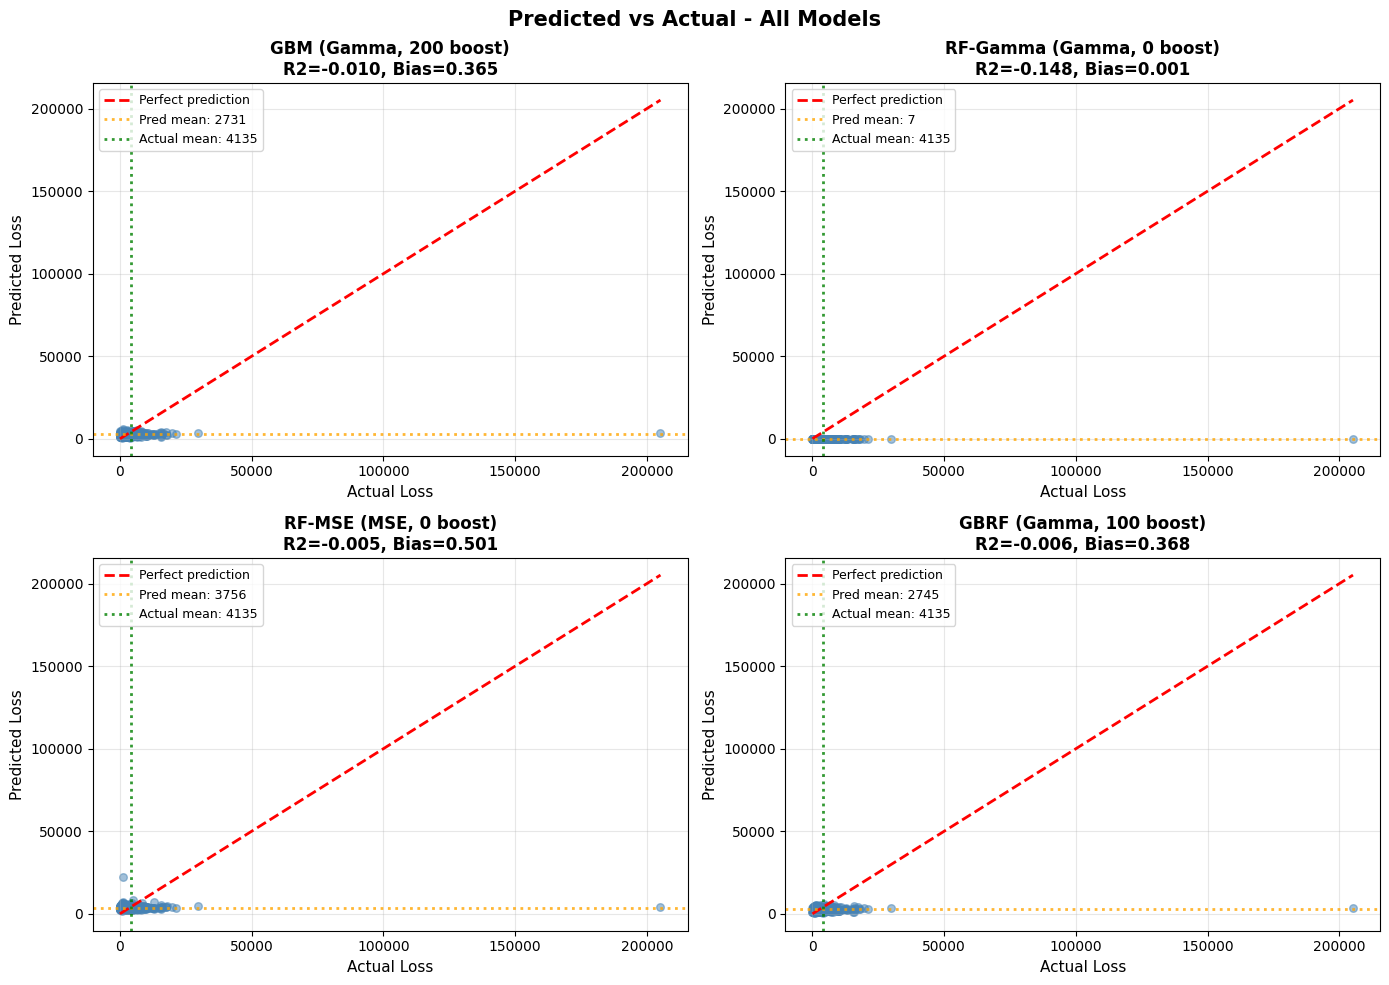

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = [
    ('GBM (Gamma, 200 boost)', gbm_test_pred, gbm_r2, gbm_bias_ratio),
    ('RF-Gamma (Gamma, 0 boost)', rf_test_pred, rf_r2, rf_bias_ratio),
    ('RF-MSE (MSE, 0 boost)', rf_mse_test_pred, rf_mse_r2, rf_mse_bias_ratio),
    ('GBRF (Gamma, 100 boost)', gbrf_test_pred, gbrf_r2, gbrf_bias_ratio)
]

for idx, (name, pred, r2, bias) in enumerate(models):
    axes[idx].scatter(y_test, pred, alpha=0.5, s=30, color='steelblue')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                   'r--', linewidth=2, label='Perfect prediction')
    
    # Mean lines for calibration
    axes[idx].axhline(pred.mean(), color='orange', linestyle=':', 
                     alpha=0.8, linewidth=2, label=f'Pred mean: {pred.mean():.0f}')
    axes[idx].axvline(y_test.mean(), color='green', linestyle=':', 
                     alpha=0.8, linewidth=2, label=f'Actual mean: {y_test.mean():.0f}')
    
    axes[idx].set_xlabel('Actual Loss', fontsize=11)
    axes[idx].set_ylabel('Predicted Loss', fontsize=11)
    axes[idx].set_title(f'{name}\nR2={r2:.3f}, Bias={bias:.3f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9, loc='upper left')

plt.suptitle('Predicted vs Actual - All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Residual Analysis (All 4 Models)

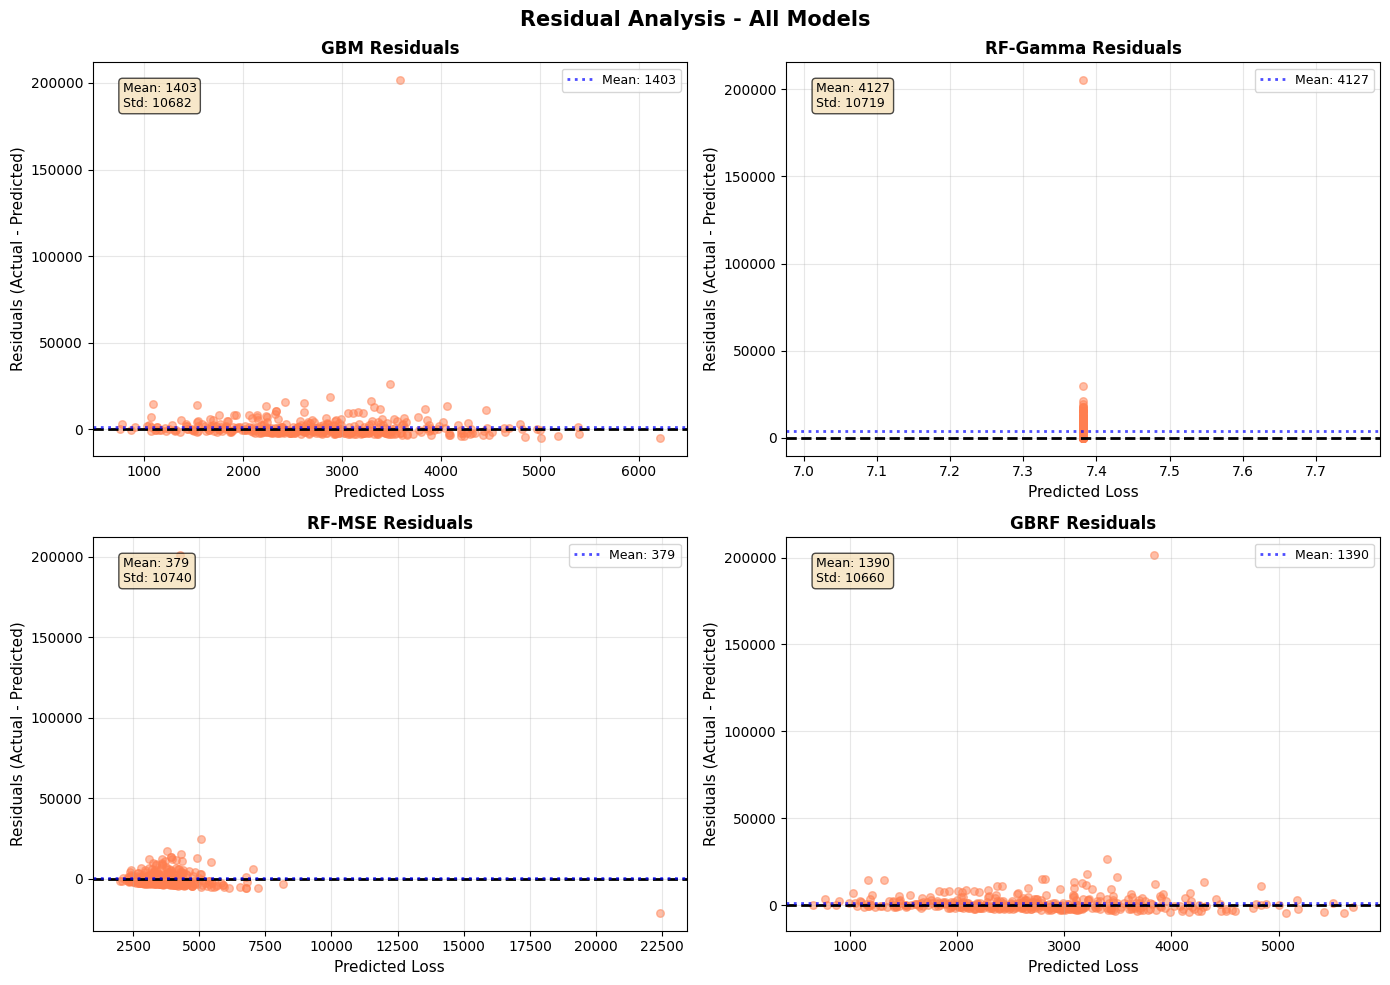

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = [
    ('GBM', gbm_test_pred),
    ('RF-Gamma', rf_test_pred),
    ('RF-MSE', rf_mse_test_pred),
    ('GBRF', gbrf_test_pred)
]

for idx, (name, pred) in enumerate(models):
    residuals = y_test.values - pred
    
    axes[idx].scatter(pred, residuals, alpha=0.5, s=30, color='coral')
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=2)
    axes[idx].axhline(y=residuals.mean(), color='blue', linestyle=':', 
                     alpha=0.7, linewidth=2, label=f'Mean: {residuals.mean():.0f}')
    
    # Statistics box
    stats_text = f'Mean: {residuals.mean():.0f}\nStd: {residuals.std():.0f}'
    axes[idx].text(0.05, 0.95, stats_text,
                  transform=axes[idx].transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    axes[idx].set_xlabel('Predicted Loss', fontsize=11)
    axes[idx].set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
    axes[idx].set_title(f'{name} Residuals', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)

plt.suptitle('Residual Analysis - All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Feature Importance (All 4 Models)

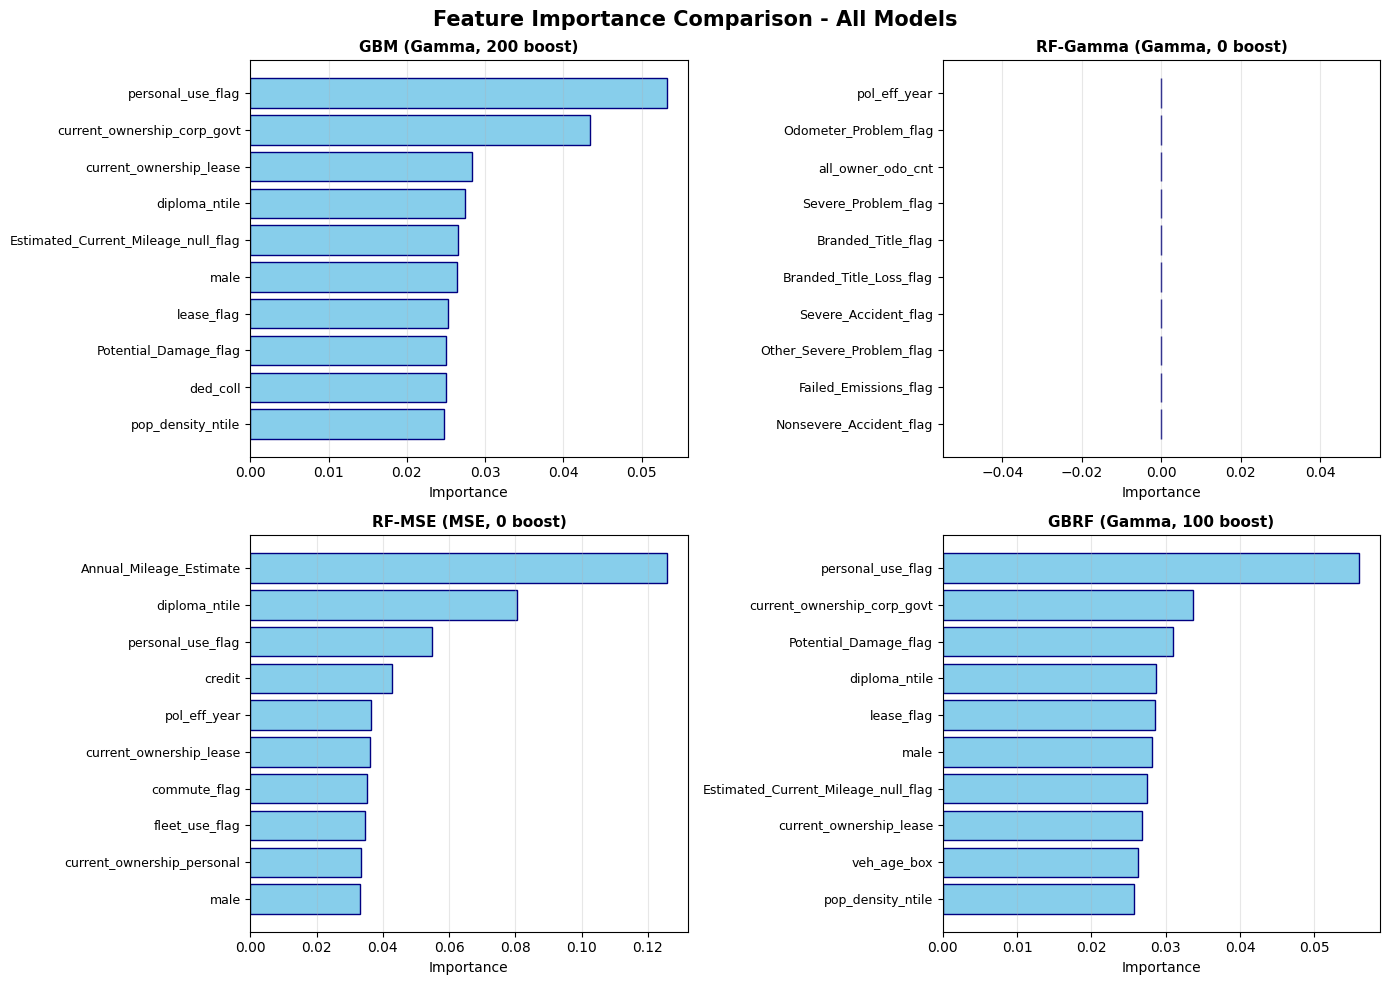

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = [
    ('GBM (Gamma, 200 boost)', gbm),
    ('RF-Gamma (Gamma, 0 boost)', rf),
    ('RF-MSE (MSE, 0 boost)', rf_mse),
    ('GBRF (Gamma, 100 boost)', gbrf)
]

for idx, (name, model) in enumerate(models):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    
    axes[idx].barh(range(len(importance_df)), 
                  importance_df['Importance'],
                  color='skyblue', edgecolor='navy')
    axes[idx].set_yticks(range(len(importance_df)))
    axes[idx].set_yticklabels(importance_df['Feature'], fontsize=9)
    axes[idx].set_xlabel('Importance', fontsize=10)
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].invert_yaxis()  # Highest importance on top
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance Comparison - All Models', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Summary

In [33]:
print('='*80)
print('REGRESSION ANALYSIS COMPLETE')
print('='*80)
print(f'Best model (R²): {'GBM' if gbm_r2 == max(gbm_r2, rf_r2, gbrf_r2) else ('RF' if rf_r2 == max(gbm_r2, rf_r2, gbrf_r2) else 'GBRF')}')
print(f'Best model (RMSE): {'GBM' if gbm_rmse == min(gbm_rmse, rf_rmse, gbrf_rmse) else ('RF' if rf_rmse == min(gbm_rmse, rf_rmse, gbrf_rmse) else 'GBRF')}')
print('='*80)

REGRESSION ANALYSIS COMPLETE
Best model (R²): GBRF
Best model (RMSE): GBRF
